# Simulación de Prueba de los valores de literatura de los parámetros B y c.

1. Usaremos una geometría con orden de magnitud de un vaso de agua, es decir, 0.1 m y a partir de esta se calculan los valores de:

$$ c = \sqrt{200 * g * H} $$

Y el parámetro de presión máxima:

$$ B = \frac{\rho_0\ c^2}{\gamma} $$

Mientras que para el paso del tiempo usamos:

$$ dt = min \left( 0.3 \frac{h}{c_0}, 0.125\ \frac{h^2}{\nu}\right) $$


In [21]:
import numpy as np

g = 9.8
H = 0.1
rho_0 = 1000
gamma = 7
h = 2.75e-3
nu = 1e-6

c = np.sqrt(200 * g * H)

B = rho_0 * c**2 / gamma

dt = min(0.3 * h/c , 0.125 * ((h**2)/nu))

print(f"c = {c:.2f}, B = {B:.2f} y dt = {dt}")

c = 14.00, B = 28000.00 y dt = 5.8928571428571415e-05


2. Construimos la geometría necesaria para la simulación.

In [22]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from Config.utils.create_ics import create_ics_txt
from Config.utils.plot_ics import plot_ics

In [23]:
INITCOND_PATH = f"{PROJECT_ROOT}/Output/init_cond/Torricelli"
PARAMETERS_PATH = f"{PROJECT_ROOT}/Config/parameters"

BOUNDARY_FILE = f"{PARAMETERS_PATH}/torricelli/torricelli_1e-1_boundary.json"
FLUID_FILE = f"{PARAMETERS_PATH}/torricelli/torricelli_1e-1_fluid.json"

INITCOND_FILE = f"{INITCOND_PATH}/torricelli1e-1_geometry.txt"
OUTPUT_LOG = f"{INITCOND_PATH}/torricelli1e-1_resume.log"

create_ics_txt(BOUNDARY_FILE, FLUID_FILE, INITCOND_FILE, OUTPUT_LOG)

[INFO] Ejecutando main.py con rutas absolutas:
  main.py:      /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/InitialConditions/main.py
  boundary:     /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Config/parameters/torricelli/torricelli_1e-1_boundary.json
  fluid:        /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Config/parameters/torricelli/torricelli_1e-1_fluid.json
  output txt:   /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/init_cond/Torricelli/torricelli1e-1_geometry.txt
  output log:   /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/init_cond/Torricelli/torricelli1e-1_resume.log

[✓] Ejecución completada correctamente.



0

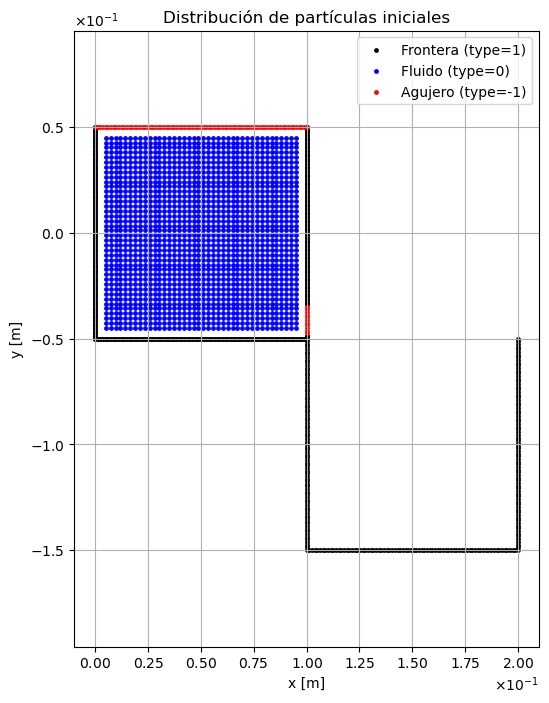

In [24]:
plot_ics(INITCOND_FILE)

3. Creamos el archivo de configuración de la simulación.

In [25]:
from Config.utils.create_simJSON import create_simulation_config

create_simulation_config(
        experiment_name="Estab_Torricelli_40x401e-1_Mac_Bc",
        input_file=INITCOND_FILE,
        base_json="AndresSimParams.json",
        B=28e3,
        c=14,
        dt=5e-5,
        g=-9.8,
        steps=4000,
        project_dir=f"{PROJECT_ROOT}/Output/Torricelli",
        neighbor_method="quadtree",
        project_root=PROJECT_ROOT
    )

✅ params.json generado: Estab_Torricelli_40x401e-1_Mac_Bc/params.json


PosixPath('/media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/Torricelli/Estab_Torricelli_40x401e-1_Mac_Bc/params.json')

In [8]:
from Config.utils.run_sim import run_single_simulation

run_single_simulation(
    experiment_dir=PROJECT_ROOT / "Output" / "Torricelli" / "Estab_Torricelli_40x401e-1_Mac_Bc",
    sim_executable=PROJECT_ROOT / "sim0PressureBoundaryLJ",
    timeout_seconds=10000
)


🚀 Ejecutando simulación: Estab_Torricelli_40x401e-1_Mac_Bc

[INFO] Leyendo parámetros desde: /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/Torricelli/Estab_Torricelli_40x401e-1_Mac_Bc/params.json
[INFO] Configurada EoS Monaghan con parámetros:
       B=28000, c=14, rho0=1000, gamma=7
Dentro de función de lectura de partículas
Separación dx/dy de frontera: 0, 0
Separación dx/dy de fluido: 0, 0
Primera partícula de frontera:
  ID: 0 pos: (0, 0.05)
  tipo: Frontera
 h: 0.00275
Última partícula de fluido:
  ID: 2389 pos: (0.095, 0.045)
  tipo: Fluido
 h: 0.00275
Se leyeron 2390 partículas desde el archivo /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/init_cond/Torricelli/torricelli1e-1_geometry.txt

[particleSummary] Número total de partículas: 2390
Fluido: 1600, Ancho: 0.09, Altura: 0.09
Frontera: 790, Ancho: 0.2, Altura: 0.2
[INFO] Ejecutando test del kernel...
Prueba del kernel completada.
Resultados guardados en: Output

In [26]:
from Config.utils.create_gnuplot import generar_script_gnuplot

BASE_PLOT = f"{PROJECT_ROOT}/Output/Torricelli/Estab_Torricelli_40x401e-1_Mac_Bc"
BASE_FILE = f"{BASE_PLOT}/Output/state_0000.txt"

generar_script_gnuplot(BASE_FILE,
                       lim=3999,
                       retardo=0.001,
                       nombre_salida="plot_est_torricelli1e-1_40x40.gp",
                       ruta_salida=BASE_PLOT
                       )

✅ Script Gnuplot generado correctamente: /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/Torricelli/Estab_Torricelli_40x401e-1_Mac_Bc/plot_est_torricelli1e-1_40x40.gp
📊 Rangos consecutivos detectados por tipo:
  Tipo 1: líneas 0–229 (230 partículas)
  Tipo -1: líneas 230–321 (92 partículas)
  Tipo 1: líneas 322–789 (468 partículas)
  Tipo 0: líneas 790–2389 (1600 partículas)


4. El sistema parece estar estable salvo por las partículas que están en la frontera, especialmente las que se encuentran pegadas en la frontera superior. Verifiquemos como se comporta la densidad y en que valor se estabiliza.

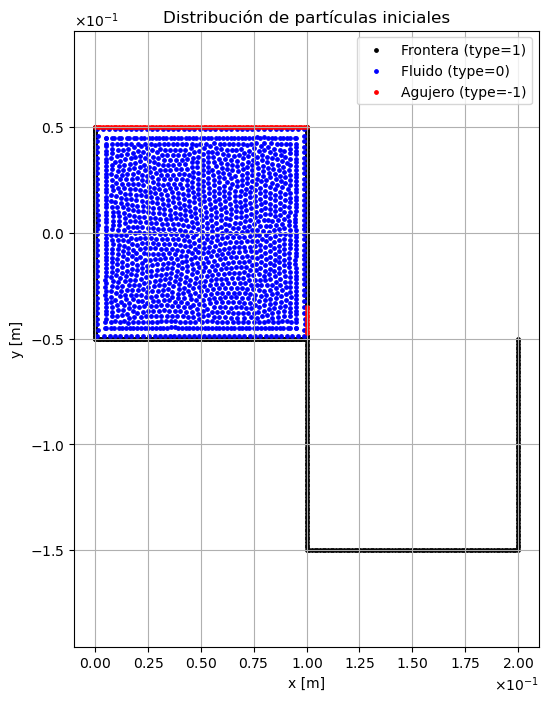

In [27]:
FINAL_STEP_ESTAB = f"{BASE_PLOT}/Output/state_3999.txt"

plot_ics(FINAL_STEP_ESTAB)

In [28]:
from Analysis.utils.estabilization_calculus import analyze_density_simulation

OUTPUT_BASE_PLOT = f"{BASE_PLOT}/Output"
result = analyze_density_simulation(sim_folder=OUTPUT_BASE_PLOT,prominence=1)

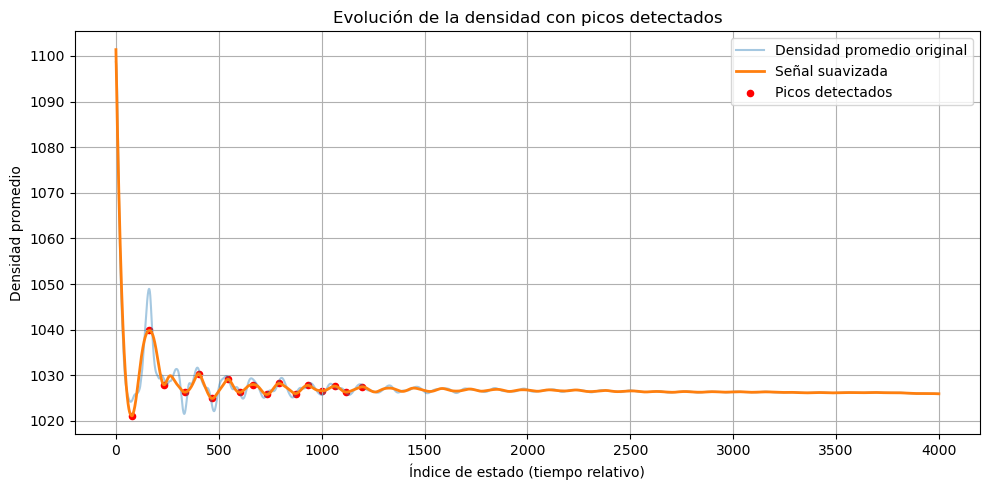

In [29]:
from Analysis.utils.estabilization_calculus import plot_density_with_peaks

plot_density_with_peaks(result)

In [30]:
import pandas as pd

# Cargar archivo (usa el nombre correcto)
df = pd.read_csv(str(FINAL_STEP_ESTAB), sep='\s+')
print(df)

        id      posx      posy      velx      vely    accelx    accely  \
0        0  0.000000  0.050000  0.000000  0.000000  0.000000  0.000000   
1        1  0.000000  0.048750  0.000000  0.000000  0.000000  0.000000   
2        2  0.000000  0.047500  0.000000  0.000000  0.000000  0.000000   
3        3  0.000000  0.046250  0.000000  0.000000  0.000000  0.000000   
4        4  0.000000  0.045000  0.000000  0.000000  0.000000  0.000000   
...    ...       ...       ...       ...       ...       ...       ...   
2385  2385  0.088045  0.049038 -0.000580 -0.000711 -3.011349 -3.485881   
2386  2386  0.090634  0.049049  0.000056 -0.000558  1.034883 -2.214617   
2387  2387  0.093221  0.049027  0.000719 -0.001000  5.719802 -5.301353   
2388  2388  0.096034  0.048924  0.000170 -0.000746  2.025736 -3.784009   
2389  2389  0.098932  0.048967  0.000040  0.000060  0.727484  1.147385   

              rho     mass      pressure        h  internalE  type  
0     1000.000000  0.00625      0.000000  

In [31]:
# Eliminar partículas del agujero de la derecha (mantener tapa)
df = df[~((df["type"] == -1) & np.isclose(df["posx"], 0.1))]

In [32]:
# ---- Ruta donde guardar ----
nombre_archivo = "Open_torricelli_40x40_1e-1_MacBc.txt"

OPEN_ICS = PROJECT_ROOT / "Output" / "init_cond" / "Torricelli" / nombre_archivo
# ---- Guardado con formateo EXACTO ----
with open(OPEN_ICS, "w") as f:
    
    # Escribir cabecera
    f.write("id posx posy velx vely accelx accely rho mass pressure h internalE type\n")
    
    # Escribir cada fila con formateo específico
    for _, row in df.iterrows():
        f.write(
            f"{int(row['id'])} "
            f"{row['posx']:.10f} "
            f"{row['posy']:.10f} "
            f"{row['velx']:.10f} "
            f"{row['vely']:.10f} "
            f"{row['accelx']:.10f} "
            f"{row['accely']:.10f} "
            f"{row['rho']:.10f} "
            f"{row['mass']:.10f} "
            f"{row['pressure']:.10f} "
            f"{row['h']:.10f} "
            f"{row['internalE']:.10f} "
            f"{int(row['type'])}\n"
        )

print("Archivo guardado en:", OPEN_ICS)

Archivo guardado en: /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/init_cond/Torricelli/Open_torricelli_40x40_1e-1_MacBc.txt


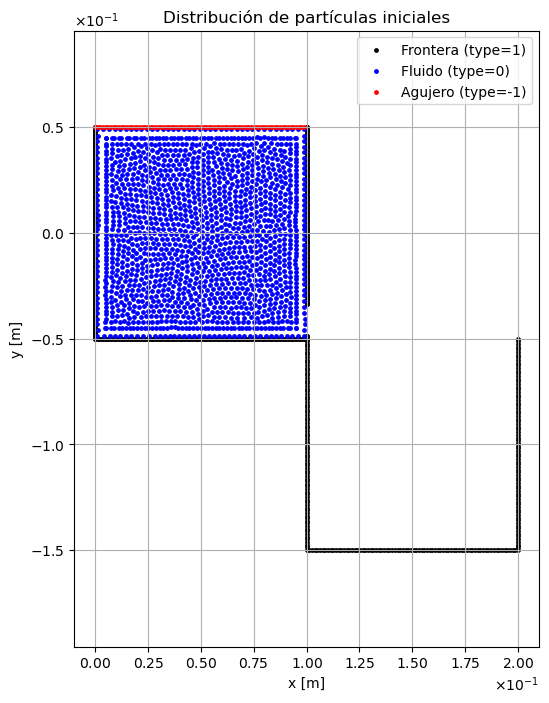

In [33]:
plot_ics(OPEN_ICS)

5. Creamos una nueva simulación para ver como se comporta el vaciado si mantenemos la tapa del fluido.

In [34]:
from Config.utils.create_simJSON import create_simulation_config

create_simulation_config(
        experiment_name="VacP1_Torricelli_40x401e-1_Mac_Bc",
        input_file=OPEN_ICS,
        base_json="AndresSimParams.json",
        B=28e3,
        c=14,
        dt=5e-5,
        g=-9.8,
        steps=20000,
        project_dir=f"{PROJECT_ROOT}/Output/Torricelli",
        neighbor_method="quadtree",
        project_root=PROJECT_ROOT
    )

✅ params.json generado: VacP1_Torricelli_40x401e-1_Mac_Bc/params.json


PosixPath('/media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/Torricelli/VacP1_Torricelli_40x401e-1_Mac_Bc/params.json')

In [57]:
from Config.utils.run_sim import run_single_simulation

run_single_simulation(
    experiment_dir=PROJECT_ROOT / "Output" / "Torricelli" / "VacP1_Torricelli_40x401e-1_Mac_Bc",
    sim_executable=PROJECT_ROOT / "sim0PressureBoundaryLJ",
    timeout_seconds=10000
)


🚀 Ejecutando simulación: VacP1_Torricelli_40x401e-1_Mac_Bc

[INFO] Leyendo parámetros desde: /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/Torricelli/VacP1_Torricelli_40x401e-1_Mac_Bc/params.json
[INFO] Configurada EoS Monaghan con parámetros:
       B=28000, c=14, rho0=1000, gamma=7
Dentro de función de lectura de partículas
Separación dx/dy de frontera: 0, 0
Separación dx/dy de fluido: 0, 0
Primera partícula de frontera:
  ID: 0 pos: (0, 0.05)
  tipo: Frontera
 h: 0.00275
Última partícula de fluido:
  ID: 2389 pos: (0.0989323, 0.0489671)
  tipo: Fluido
 h: 0.00275
Se leyeron 2378 partículas desde el archivo /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/init_cond/Torricelli/Open_torricelli_40x40_1e-1_MacBc.txt

[particleSummary] Número total de partículas: 2378
Fluido: 1600, Ancho: 0.098076, Altura: 0.0980631
Frontera: 778, Ancho: 0.2, Altura: 0.2
[INFO] Ejecutando test del kernel...
Prueba del kernel completada.
Resul

KeyboardInterrupt: 

In [35]:
from Config.utils.create_gnuplot import generar_script_gnuplot

BASE_PLOT_VAC1 = f"{PROJECT_ROOT}/Output/Torricelli/VacP1_Torricelli_40x401e-1_Mac_Bc"
BASE_FILE_VAC1 = f"{BASE_PLOT_VAC1}/Output/state_0000.txt"

generar_script_gnuplot(BASE_FILE_VAC1,
                       lim=9999,
                       retardo=0.001,
                       nombre_salida="plot_vac_torricelli1e-1_40x40.gp",
                       ruta_salida=BASE_PLOT_VAC1
                       )

✅ Script Gnuplot generado correctamente: /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/Torricelli/VacP1_Torricelli_40x401e-1_Mac_Bc/plot_vac_torricelli1e-1_40x40.gp
📊 Rangos consecutivos detectados por tipo:
  Tipo 1: líneas 0–229 (230 partículas)
  Tipo -1: líneas 230–309 (80 partículas)
  Tipo 1: líneas 310–777 (468 partículas)
  Tipo 0: líneas 778–2377 (1600 partículas)


6. Eliminemos las partículas de la tapa superior para ver como se comporta la superficie libre:

In [36]:
# Eliminar partículas del agujero de la derecha (mantener tapa)
df_sinTapa = df[df["type"] != -1]

print(df_sinTapa)

        id      posx      posy      velx      vely    accelx    accely  \
0        0  0.000000  0.050000  0.000000  0.000000  0.000000  0.000000   
1        1  0.000000  0.048750  0.000000  0.000000  0.000000  0.000000   
2        2  0.000000  0.047500  0.000000  0.000000  0.000000  0.000000   
3        3  0.000000  0.046250  0.000000  0.000000  0.000000  0.000000   
4        4  0.000000  0.045000  0.000000  0.000000  0.000000  0.000000   
...    ...       ...       ...       ...       ...       ...       ...   
2385  2385  0.088045  0.049038 -0.000580 -0.000711 -3.011349 -3.485881   
2386  2386  0.090634  0.049049  0.000056 -0.000558  1.034883 -2.214617   
2387  2387  0.093221  0.049027  0.000719 -0.001000  5.719802 -5.301353   
2388  2388  0.096034  0.048924  0.000170 -0.000746  2.025736 -3.784009   
2389  2389  0.098932  0.048967  0.000040  0.000060  0.727484  1.147385   

              rho     mass      pressure        h  internalE  type  
0     1000.000000  0.00625      0.000000  

In [38]:
# ---- Ruta donde guardar ----
nombre_archivo = "Open_st_torricelli_40x40_1e-1_MacBc.txt"

OPEN_ICS_SIN_TAPA = PROJECT_ROOT / "Output" / "init_cond" / "Torricelli" / nombre_archivo
# ---- Guardado con formateo EXACTO ----
with open(OPEN_ICS_SIN_TAPA, "w") as f:
    
    # Escribir cabecera
    f.write("id posx posy velx vely accelx accely rho mass pressure h internalE type\n")
    
    # Escribir cada fila con formateo específico
    for _, row in df_sinTapa.iterrows():
        f.write(
            f"{int(row['id'])} "
            f"{row['posx']:.10f} "
            f"{row['posy']:.10f} "
            f"{row['velx']:.10f} "
            f"{row['vely']:.10f} "
            f"{row['accelx']:.10f} "
            f"{row['accely']:.10f} "
            f"{row['rho']:.10f} "
            f"{row['mass']:.10f} "
            f"{row['pressure']:.10f} "
            f"{row['h']:.10f} "
            f"{row['internalE']:.10f} "
            f"{int(row['type'])}\n"
        )

print("Archivo guardado en:", OPEN_ICS_SIN_TAPA)

Archivo guardado en: /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/init_cond/Torricelli/Open_st_torricelli_40x40_1e-1_MacBc.txt


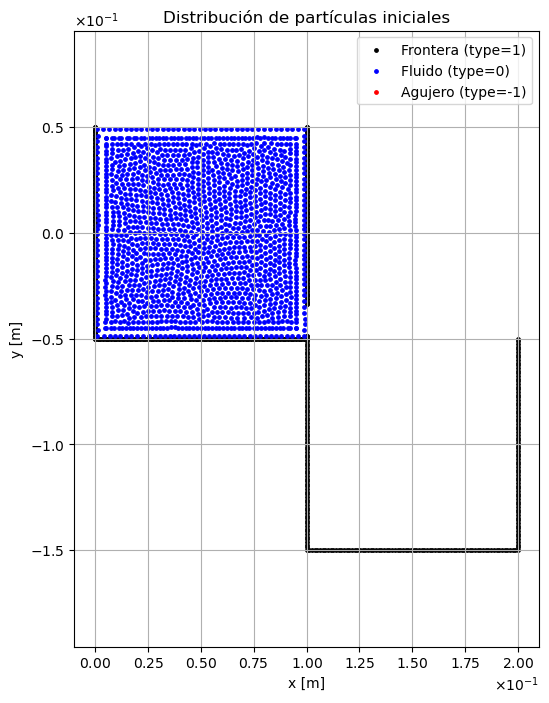

In [39]:
plot_ics(OPEN_ICS_SIN_TAPA)

In [42]:
from Config.utils.create_simJSON import create_simulation_config

create_simulation_config(
        experiment_name="Vac_ST_P1_Torricelli_40x401e-1_Mac_Bc",
        input_file=OPEN_ICS_SIN_TAPA,
        base_json="AndresSimParams.json",
        B=28e3,
        c=14,
        dt=5e-5,
        g=-9.8,
        steps=2000,
        project_dir=f"{PROJECT_ROOT}/Output/Torricelli",
        neighbor_method="quadtree",
        project_root=PROJECT_ROOT
    )

✅ params.json generado: Vac_ST_P1_Torricelli_40x401e-1_Mac_Bc/params.json


PosixPath('/media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/Torricelli/Vac_ST_P1_Torricelli_40x401e-1_Mac_Bc/params.json')

In [43]:
from Config.utils.run_sim import run_single_simulation

run_single_simulation(
    experiment_dir=PROJECT_ROOT / "Output" / "Torricelli" / "Vac_ST_P1_Torricelli_40x401e-1_Mac_Bc",
    sim_executable=PROJECT_ROOT / "sim0pBoundLJ",
    timeout_seconds=10000
)


🚀 Ejecutando simulación: Vac_ST_P1_Torricelli_40x401e-1_Mac_Bc

[INFO] Leyendo parámetros desde: /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/Torricelli/Vac_ST_P1_Torricelli_40x401e-1_Mac_Bc/params.json
[INFO] Configurada EoS Monaghan con parámetros:
       B=28000, c=14, rho0=1000, gamma=7
Dentro de función de lectura de partículas
Separación dx/dy de frontera: 0, 0
Separación dx/dy de fluido: 0, 0
Primera partícula de frontera:
  ID: 0 pos: (0, 0.05)
  tipo: Frontera
 h: 0.00275
Última partícula de fluido:
  ID: 2389 pos: (0.0989323, 0.0489671)
  tipo: Fluido
 h: 0.00275
Se leyeron 2298 partículas desde el archivo /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/init_cond/Torricelli/Open_st_torricelli_40x40_1e-1_MacBc.txt

[particleSummary] Número total de partículas: 2298
Fluido: 1600, Ancho: 0.098076, Altura: 0.0980631
Frontera: 698, Ancho: 0.2, Altura: 0.2
[INFO] Ejecutando test del kernel...
Prueba del kernel comple

In [45]:
from Config.utils.create_gnuplot import generar_script_gnuplot

BASE_PLOT_VAC1_ST = f"{PROJECT_ROOT}/Output/Torricelli/Vac_ST_P1_Torricelli_40x401e-1_Mac_Bc"
BASE_FILE_VAC1_ST = f"{BASE_PLOT_VAC1_ST}/Output/state_0000.txt"

generar_script_gnuplot(BASE_FILE_VAC1_ST,
                       lim=1999,
                       retardo=0.0001,
                       nombre_salida="plot_vac_st_torricelli1e-1_40x40.gp",
                       ruta_salida=BASE_PLOT_VAC1_ST
                       )

✅ Script Gnuplot generado correctamente: /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/Torricelli/Vac_ST_P1_Torricelli_40x401e-1_Mac_Bc/plot_vac_st_torricelli1e-1_40x40.gp
📊 Rangos consecutivos detectados por tipo:
  Tipo 1: líneas 0–697 (698 partículas)
  Tipo 0: líneas 698–2297 (1600 partículas)


7. Al parecer la presión interna dentro del recipiente es muy alto, para generar estabilización se puede recortar a la mitad las partículas de fluido que existen dentro del recipiente y luego se permite la estabilización.

In [49]:
# Partimos de la condición inicial

df_init = pd.read_csv(str(INITCOND_FILE), sep='\s+')

In [50]:
# Eliminar partículas del fluido por encima de 0

df_fluid_50inf = df_init[~((df_init["type"] == 0) & (df_init["posy"] > 0.0))]

print(df_fluid_50inf)

        id      posx      posy  velx  vely  accelx  accely     rho     mass  \
0        0  0.000000  0.050000   0.0   0.0     0.0     0.0  1000.0  0.00625   
1        1  0.000000  0.048750   0.0   0.0     0.0     0.0  1000.0  0.00625   
2        2  0.000000  0.047500   0.0   0.0     0.0     0.0  1000.0  0.00625   
3        3  0.000000  0.046250   0.0   0.0     0.0     0.0  1000.0  0.00625   
4        4  0.000000  0.045000   0.0   0.0     0.0     0.0  1000.0  0.00625   
...    ...       ...       ...   ...   ...     ...     ...     ...      ...   
1585  1585  0.085769 -0.001154   0.0   0.0     0.0     0.0  1000.0  0.00625   
1586  1586  0.088077 -0.001154   0.0   0.0     0.0     0.0  1000.0  0.00625   
1587  1587  0.090385 -0.001154   0.0   0.0     0.0     0.0  1000.0  0.00625   
1588  1588  0.092692 -0.001154   0.0   0.0     0.0     0.0  1000.0  0.00625   
1589  1589  0.095000 -0.001154   0.0   0.0     0.0     0.0  1000.0  0.00625   

      pressure        h  internalE  type  
0       

In [51]:
# ---- Ruta donde guardar ----
nombre_archivo = "Fluid50_inf_torricelli_40x40_1e-1_MacBc.txt"

OPEN_ICS_F50_INF = PROJECT_ROOT / "Output" / "init_cond" / "Torricelli" / nombre_archivo
# ---- Guardado con formateo EXACTO ----
with open(OPEN_ICS_F50_INF, "w") as f:
    
    # Escribir cabecera
    f.write("id posx posy velx vely accelx accely rho mass pressure h internalE type\n")
    
    # Escribir cada fila con formateo específico
    for _, row in df_fluid_50inf.iterrows():
        f.write(
            f"{int(row['id'])} "
            f"{row['posx']:.10f} "
            f"{row['posy']:.10f} "
            f"{row['velx']:.10f} "
            f"{row['vely']:.10f} "
            f"{row['accelx']:.10f} "
            f"{row['accely']:.10f} "
            f"{row['rho']:.10f} "
            f"{row['mass']:.10f} "
            f"{row['pressure']:.10f} "
            f"{row['h']:.10f} "
            f"{row['internalE']:.10f} "
            f"{int(row['type'])}\n"
        )

print("Archivo guardado en:", OPEN_ICS_F50_INF)

Archivo guardado en: /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/init_cond/Torricelli/Fluid50_inf_torricelli_40x40_1e-1_MacBc.txt


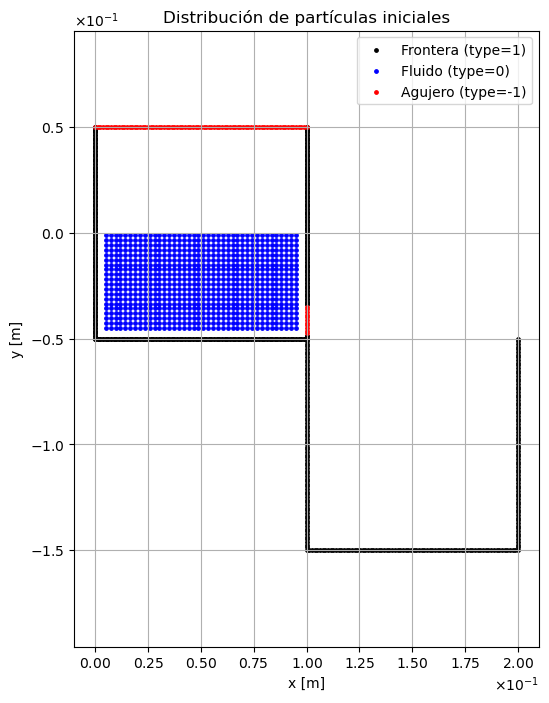

In [52]:
plot_ics(OPEN_ICS_F50_INF)

In [58]:
from Config.utils.create_simJSON import create_simulation_config

create_simulation_config(
        experiment_name="Estab_f50_Torricelli_40x401e-1_Mac_Bc",
        input_file=OPEN_ICS_F50_INF,
        base_json="AndresSimParams.json",
        B=28e3,
        c=14,
        dt=5e-5,
        g=-9.8,
        steps=7000,
        project_dir=f"{PROJECT_ROOT}/Output/Torricelli",
        neighbor_method="quadtree",
        project_root=PROJECT_ROOT
    )

✅ params.json generado: Estab_f50_Torricelli_40x401e-1_Mac_Bc/params.json


PosixPath('/media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/Torricelli/Estab_f50_Torricelli_40x401e-1_Mac_Bc/params.json')

In [59]:
from Config.utils.run_sim import run_single_simulation

run_single_simulation(
    experiment_dir=PROJECT_ROOT / "Output" / "Torricelli" / "Estab_f50_Torricelli_40x401e-1_Mac_Bc",
    sim_executable=PROJECT_ROOT / "sim0pBoundLJ",
    timeout_seconds=10000
)


🚀 Ejecutando simulación: Estab_f50_Torricelli_40x401e-1_Mac_Bc

[INFO] Leyendo parámetros desde: /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/Torricelli/Estab_f50_Torricelli_40x401e-1_Mac_Bc/params.json
[INFO] Configurada EoS Monaghan con parámetros:
       B=28000, c=14, rho0=1000, gamma=7
Dentro de función de lectura de partículas
Separación dx/dy de frontera: 0, 0
Separación dx/dy de fluido: 0, 0
Primera partícula de frontera:
  ID: 0 pos: (0, 0.05)
  tipo: Frontera
 h: 0.00275
Última partícula de fluido:
  ID: 1589 pos: (0.095, -0.00115385)
  tipo: Fluido
 h: 0.00275
Se leyeron 1590 partículas desde el archivo /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/init_cond/Torricelli/Fluid50_inf_torricelli_40x40_1e-1_MacBc.txt

[particleSummary] Número total de partículas: 1590
Fluido: 800, Ancho: 0.09, Altura: 0.0438462
Frontera: 790, Ancho: 0.2, Altura: 0.2
[INFO] Ejecutando test del kernel...
Prueba del kernel completad

In [60]:
from Config.utils.create_gnuplot import generar_script_gnuplot

BASE_PLOT_F50_ESTAB = f"{PROJECT_ROOT}/Output/Torricelli/Estab_f50_Torricelli_40x401e-1_Mac_Bc"
BASE_FILE_F50_ESTAB = f"{BASE_PLOT_F50_ESTAB}/Output/state_0000.txt"

generar_script_gnuplot(BASE_FILE_F50_ESTAB,
                       lim=6999,
                       retardo=0.0001,
                       nombre_salida="plot_estab_f50_torricelli1e-1_40x40.gp",
                       ruta_salida=BASE_PLOT_F50_ESTAB
                       )

✅ Script Gnuplot generado correctamente: /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/Torricelli/Estab_f50_Torricelli_40x401e-1_Mac_Bc/plot_estab_f50_torricelli1e-1_40x40.gp
📊 Rangos consecutivos detectados por tipo:
  Tipo 1: líneas 0–229 (230 partículas)
  Tipo -1: líneas 230–321 (92 partículas)
  Tipo 1: líneas 322–789 (468 partículas)
  Tipo 0: líneas 790–1589 (800 partículas)
